Title - Spam Mail Prediction using TF-IDF Vectorizer and Logistic Regression

1. Importing The Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


Loading the Dataset

In [3]:
spam = pd.read_csv("dataset/spam.csv")
spam.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
spam.shape

(5572, 2)

3. Exploratory Data Analysis

In [6]:
spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
spam.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [ ]:
spam.isnull().sum()  #Data is clean and there are no null values in the dataset.

Category    0
Message     0
dtype: int64

In [9]:
encoder = LabelEncoder()
spam['Category'] = encoder.fit_transform(spam['Category'])

print(spam.head())

   Category                                            Message
0         0  Go until jurong point, crazy.. Available only ...
1         0                      Ok lar... Joking wif u oni...
2         1  Free entry in 2 a wkly comp to win FA Cup fina...
3         0  U dun say so early hor... U c already then say...
4         0  Nah I don't think he goes to usf, he lives aro...


4. Data Visualization

Category
0    4825
1     747
Name: count, dtype: int64


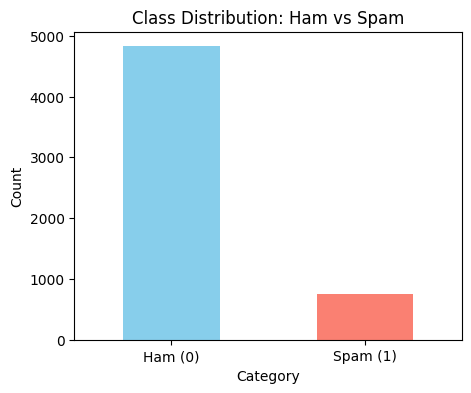

In [12]:
print(spam['Category'].value_counts()) #Data is skewed towards ham

plt.figure(figsize=(5, 4))
spam['Category'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Ham (0)', 'Spam (1)'], rotation=0)
plt.title('Class Distribution: Ham vs Spam')
plt.ylabel('Count')
plt.savefig('output/class_distribution.png')
plt.show()

5. Train Test Split

In [13]:
X = spam['Message']
Y = spam['Category']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=3
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


6. Text Feature Extraction (TF-IDF)

In [14]:
vectorizer = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)

X_train_features = vectorizer.fit_transform(X_train)
X_test_features = vectorizer.transform(X_test)

print("Shape of training features:", X_train_features.shape)
print("Shape of testing features:", X_test_features.shape)

Shape of training features: (4457, 7431)
Shape of testing features: (1115, 7431)


7. Model Training